# Analysis of the JS distance for different settings

This notebook analyzes the error in the DBN vs. Monte Carlo simulation of the ground truth. 

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Function to read the results file for the specified settings
def read_results_file(indicator,
                      inference_method,
                      nreps):
    filename = f'../results/indicator-{indicator}_inference-{inference_method}_nreps-{nreps}_results.csv'
    df = pd.read_csv(filename)
    return df
    

In [3]:
INDICATOR = False
INFERENCE_METHOD = 'exact-lazyprop' 
NREPS = 30
df1 = read_results_file(INDICATOR, INFERENCE_METHOD, NREPS)

INDICATOR = True
INFERENCE_METHOD = 'exact-lazyprop'
NREPS = 30
df2 = read_results_file(INDICATOR, INFERENCE_METHOD, NREPS)

In [4]:
# Find the average of the 'jsd' in df1 where intv_type = 'conditional' and 'number_conditional_events' > 50
df1_conditional_jsd = df1[(df1['intv_type'] == 'conditional') & (df1['num_conditional_events'] > 50)]['jsd'].mean()
print(f'Average JSD for df1 where intv_type = conditional: {df1_conditional_jsd}')

Average JSD for df1 where intv_type = conditional: 0.08773531265153915


In [5]:
# Find the number of rows in df1 where intv_type = 'conditional' and 'number_conditional_events' > 50
df1_conditional_rows = df1[(df1['intv_type'] == 'conditional') & (df1['num_conditional_events'] > 50)].shape[0]
print(f'Number of rows in df1 where intv_type = conditional: {df1_conditional_rows}')
# Get a list of rows in df1 where intv_type = 'conditional' and 'number_conditional_events' > 50
df1_conditional_rows_list = df1[(df1['intv_type'] == 'conditional') & (df1['num_conditional_events'] > 50)].exp_num.tolist()
print(f'List of rows in df1 where intv_type = conditional: {df1_conditional_rows_list}')


Number of rows in df1 where intv_type = conditional: 24
List of rows in df1 where intv_type = conditional: [1, 5, 7, 8, 11, 12, 18, 22, 23, 25, 26, 27, 29, 35, 36, 37, 39, 40, 41, 43, 44, 46, 48, 50]


In [6]:
# Find the average of the 'jsd' in df2 where intv_type = 'conditional' and 'exp_num' is in df1_conditional_rows_list
df2_conditional_vals = df2[(df2['intv_type'] == 'conditional') & (df2['exp_num'].isin(df1_conditional_rows_list))][['exp_num', 'jsd']]
print(f'JSD values for df2 where intv_type = conditional and exp_num is in df1_conditional_rows_list: \n{df2_conditional_vals}')
df2_conditional_jsd = df2_conditional_vals['jsd'].mean()
print(f'Average JSD for df2 where intv_type = conditional and exp_num is in df1_conditional_rows_list: {df2_conditional_jsd}')

JSD values for df2 where intv_type = conditional and exp_num is in df1_conditional_rows_list: 
    exp_num       jsd
0         1  0.063262
3         5  0.031589
5         7  0.162825
6         8  0.120967
8        11  0.090113
9        12  0.091442
14       18  0.119370
18       22  0.041338
19       23  0.039771
20       25  0.079003
21       26  0.138646
22       27  0.192249
24       29  0.104351
30       35  0.081942
31       36  0.100600
32       37  0.094853
34       39  0.076400
35       40  0.082298
36       41  0.060074
37       43  0.081461
38       44  0.044026
40       46  0.139003
42       48  0.057905
44       50  0.025954
Average JSD for df2 where intv_type = conditional and exp_num is in df1_conditional_rows_list: 0.08831003748107842


In [7]:
# Find the average of the 'jsd' in df1 where intv_type = 'parameter_intervention'
df1_param_intv = df1.loc[df1['intv_type'] == 'parameter_intervention', 'jsd'].mean()
# Find the average of the 'jsd' in df2 where intv_type = 'parameter_intervention'
df2_param_intv = df2.loc[df2['intv_type'] == 'parameter_intervention', 'jsd'].mean()
print(f'Average JSD for parameter intervention using all parent values: {df1_param_intv}')
print(f'Average JSD for parameter intervention using indicator parent values: {df2_param_intv}')

Average JSD for parameter intervention using all parent values: 0.054971623558243594
Average JSD for parameter intervention using indicator parent values: 0.04763549478284055


In [8]:
# Find the average of the 'jsd' in df1 where intv_type = 'interventional'
df1_int_intv = df1.loc[df1['intv_type'] == 'interventional', 'jsd'].mean()
# Find the average of the 'jsd' in df2 where intv_type = 'interventional'
df2_int_intv = df2.loc[df2['intv_type'] == 'interventional', 'jsd'].mean()
print(f'Average JSD for interventional intervention using all parent values: {df1_int_intv}')
print(f'Average JSD for interventional intervention using indicator parent values: {df2_int_intv}')

Average JSD for interventional intervention using all parent values: 0.06259928160693337
Average JSD for interventional intervention using indicator parent values: 0.052421034632930574


In [9]:
# Find the average of the 'jsd' in df1 where intv_type = 'additive' or 'subtractive'
df1_add_sub_intv = df1.loc[df1['intv_type'].isin(['additive', 'subtractive']), 'jsd'].mean()
# Find the average of the 'jsd' in df2 where intv_type = 'additive' or 'subtractive'
df2_add_sub_intv = df2.loc[df2['intv_type'].isin(['additive', 'subtractive']), 'jsd'].mean()
print(f'Average JSD for additive/subtractive intervention using all parent values: {df1_add_sub_intv}')
print(f'Average JSD for additive/subtractive intervention using indicator parent values: {df2_add_sub_intv}')

Average JSD for additive/subtractive intervention using all parent values: 0.06804555336052638
Average JSD for additive/subtractive intervention using indicator parent values: 0.04233055741217609


In [10]:
# Find exp_num of columns in df1 where intv_type = conditional and 'number_conditional_events' <= 50
drop_rows = df1[(df1['intv_type'] == 'conditional') & (df1['num_conditional_events'] <= 50)].exp_num.tolist()
print(f'List of rows in df1 where intv_type = conditional and number_conditional_events <= 50: {drop_rows}')

List of rows in df1 where intv_type = conditional and number_conditional_events <= 50: [2, 4, 13, 14, 15, 17, 19, 20, 21, 28, 31, 32, 33, 34, 38, 45, 47, 49]


In [11]:
# Drop rows in df1 where expt_num is in drop_rows
df1 = df1[~df1['exp_num'].isin(drop_rows)]

# Find the average of the 'jsd' in df1
df1_jsd = df1['jsd'].mean()
print(f'Average JSD for df1: {df1_jsd}')

# Drop rows in df2 where expt_num is in drop_rows
df2 = df2[~df2['exp_num'].isin(drop_rows)]
df2_jsd  = df2['jsd'].mean()
print(f'Average JSD for df2: {df2_jsd}')

# Find the percentage decrease in error using df2 compared to df1
percent_decrease = ((df1_jsd - df2_jsd) / df1_jsd) * 100
print(f'Percentage decrease in error using df2 compared to df1: {percent_decrease}')

Average JSD for df1: 0.06545590259141719
Average JSD for df2: 0.061373365484791435
Percentage decrease in error using df2 compared to df1: 6.2370801486145435


In [12]:
# Find the percent change in 'inference_time' using df2 compared to df1
df1_inference_time = df1['inference_time'].mean()
df2_inference_time = df2['inference_time'].mean()
percent_change_inference_time = ((df1_inference_time - df2_inference_time) / df1_inference_time) * 100
print(f'Percent change in inference time using df2 compared to df1: {percent_change_inference_time}')

Percent change in inference time using df2 compared to df1: -1.3135568522242937


In [13]:
# Find the average of the 'jsd' in df1 where intv_type = 'interventional' or 'additive' or 'subtractive' or 'parameter_intervention'
df1_all_intv = df1.loc[df1['intv_type'].isin(['interventional', 'additive', 'subtractive', 'parameter_intervention']), 'jsd'].mean()
# Find the average of the 'jsd' in df2 where intv_type = 'interventional' or 'additive' or 'subtractive' or 'parameter_intervention'
df2_all_intv = df2.loc[df2['intv_type'].isin(['interventional', 'additive', 'subtractive', 'parameter_intervention']), 'jsd'].mean()
print(f'Average JSD for all interventions using all parent values: {df1_all_intv}')
print(f'Average JSD for all interventions using indicator parent values: {df2_all_intv}')

# Find the percentage decrease in error using df2 compared to df1
percent_decrease = ((df1_all_intv - df2_all_intv) / df1_all_intv) * 100
print(f'Percentage decrease in error using indicator parent values: {percent_decrease:.3f}%')

Average JSD for all interventions using all parent values: 0.0618672727830754
Average JSD for all interventions using indicator parent values: 0.047462362275982405
Percentage decrease in error using indicator parent values: 23.284%


In [14]:
df1_types = df1.copy()
# Create an additional column in df1_types called 'intv_category' which will have the values 'conditional', 'parameter_intervention', 'interventional', 'additive/subtractive' based on the value of 'intv_type'
df1_types['Intervention Type'] = df1_types['intv_type'].apply(lambda x: 'Conditional' if x == 'conditional' else ('Parameter' if x == 'parameter_intervention' else ('Queue Length' if x == 'interventional' else 'Add/Sub')))

/tmp/ipykernel_598400/4289640214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Intervention Type', y='jsd', data=df1_types, palette='Set2', legend=True, gap=0.1, width=0.8)


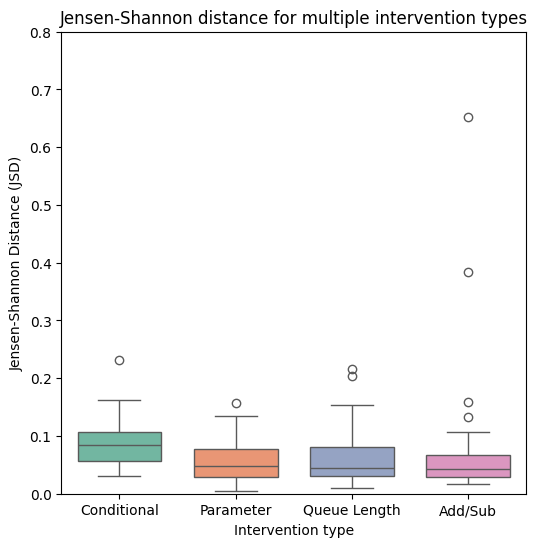

In [15]:
# Create a boxplot of the JSD values for df1. The y-axis is the JSD values, and the x-axis is the intervention type. 
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='jsd', data=df1_types, palette='Set2', legend=True, gap=0.1, width=0.8)
plt.title('Jensen-Shannon distance for multiple intervention types')
plt.xlabel('Intervention type')
plt.ylabel('Jensen-Shannon Distance (JSD)')
plt.ylim(0, 0.8)
plt.show()

In [ ]:
# Create a plot that is good for the journal paper. More professional.
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 6), 
                               gridspec_kw={'height_ratios': [0.03, 1]})

# Adjust spacing between the plots
fig.subplots_adjust(hspace=0.03)

sns.boxplot(x='Intervention Type', y='jsd', data=df1_types, gap=0.2, width=0.6, legend=True, ax=ax2, fill=False, linecolor='black', color='black', linewidth=0.8, fliersize=1.5)
ax2.set_ylim(0, 0.45)

sns.boxplot(x='Intervention Type', y='jsd', data=df1_types, gap=0.2, width=1.0, legend=False, ax=ax1)
# Remove y-axis labels from the top plot
ax1.set_ylabel('')
ax1.set_ylim(0.99, 1.0)
# Show only the top ytick label on the top plot
ax1.set_yticks([1])
ax1.set_yticklabels([1.0])

# Hide the spines between the plots
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Hide the x-axis tick labels on the first plot
ax1.tick_params(labelbottom=False)

# Add diagonal lines to indicate the axis break
d = 0.015  # Size of the diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

d = 0.015  # Size of the diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# How to remove the '''' lines from the plot
ax1.xaxis.tick_top()
# Do not show ticks on the top plot
ax1.tick_params(top=False)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top

# Show the plot
# Add title to the full plot
plt.suptitle(r'Variability of JSD across query types')
plt.xlabel(r'Query type')
plt.ylabel(f'Jensen-Shannon distance (JSD)')
plt.tight_layout()
plt.savefig('../figures/journal_figures/results-baseline-jsd.png', dpi=300)
plt.show()

/tmp/ipykernel_598400/1612231837.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Intervention Type', y='inference_time', data=df1_types, palette='Set2', legend=True, gap=0.1, width=0.8)


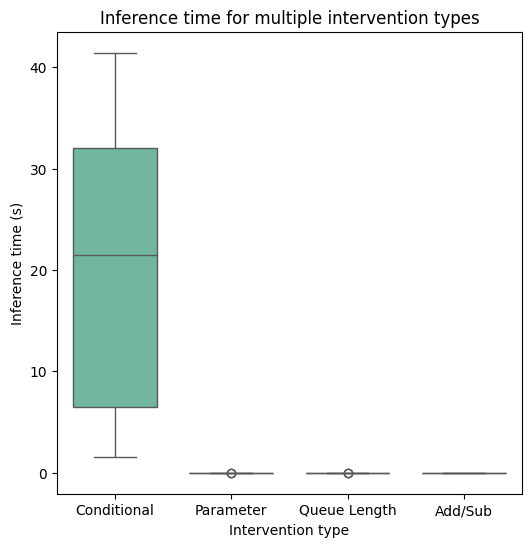

In [16]:
# Create a boxplot of the inference times for df1_types. The y-axis is the inference times, and the x-axis is the intervention type.
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_time', data=df1_types, palette='Set2', legend=True, gap=0.1, width=0.8)
plt.title('Inference time for multiple intervention types')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
plt.show()

In [ ]:
# Create a boxplot of the inference times for df1_types. We should have two y-axes, one for the 'Conditional' intervention type on the left y-axis and the other for all other intervention types on the right y-axis. 
fig, ax1 = plt.subplots(figsize=(6, 6))
ax2 = ax1.twinx()
# Create a boxplot for the 'Conditional' intervention type on the left y-axis
sns.boxplot(x='Intervention Type', y='inference_time', data=df1_types[df1_types['Intervention Type'] == 'Conditional'], ax=ax1, width=0.6, fill=False, linecolor='black', color='black', linewidth=0.8, fliersize=1.5)
ax1.set_ylabel(r'Inference time (s) for $Q^{\text{cond}}$')
ax1.set_ylim(0, 50)
# Create a boxplot for all other intervention types on the right y-axis
sns.boxplot(x='Intervention Type', y='inference_time', data=df1_types[df1_types['Intervention Type'] != 'Conditional'], ax=ax2, width=0.6, fill=False, linecolor='black', color='black', linewidth=0.8, fliersize=1.5)
ax2.set_ylabel(r'Inference time (s) for $Q^{\text{param}}, Q^{\text{qint}}, Q^{\text{qchg}}$')
ax2.set_ylim(0, 0.01)
# Draw a vertical line to separate the two boxplots
ax1.axvline(0.5, color='black', linestyle='--')
# Set the title
plt.title('Inference time across query types')
ax1.set_xlabel('Query type')
plt.tight_layout()
plt.savefig('../figures/journal_figures/results-baseline-inferencetime.png', dpi=300)
plt.show()

/tmp/ipykernel_598400/2358558145.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Intervention Type', y='inference_compute_time', data=df1_types, palette='Set2', legend=True, gap=0.1, width=0.8)


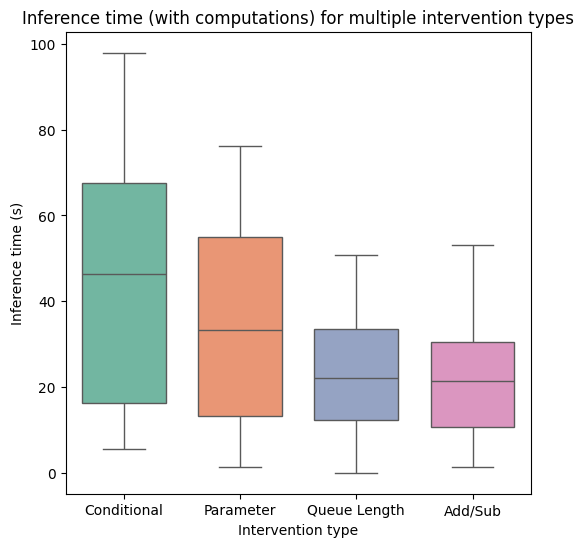

In [17]:
# Create a boxplot of the inference times for df1_types. The y-axis is the inference times, and the x-axis is the intervention type.
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_compute_time', data=df1_types, palette='Set2', legend=True, gap=0.1, width=0.8)
plt.title('Inference time (with computations) for multiple intervention types')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
plt.show()

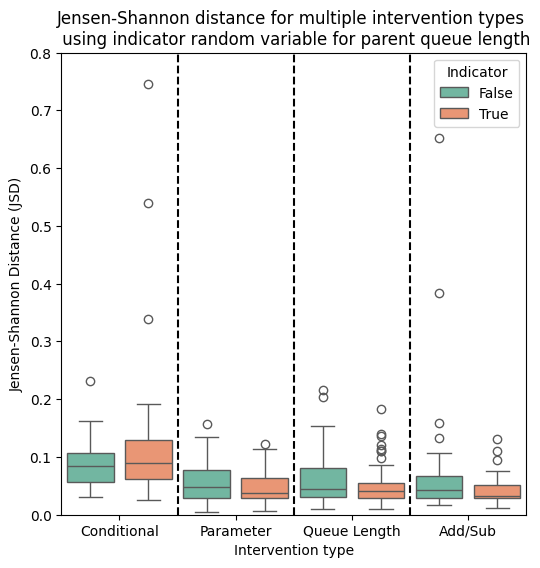

In [18]:
# Combine df1 and df2 into a single dataframe called expt_indicator_df, with an additional column called 'Indicator' which will have the values 'False' for df1 and 'True' for df2
df1['Indicator'] = False
df2['Indicator'] = True
expt_indicator_df = pd.concat([df1, df2])

# Create a column called 'Intervention Type' in expt_indicator_df which will have the values 'Conditional', 'Parameter Intervention', 'Interventional', 'Additive/Subtractive Intervention' based on the value of 'intv_type'
expt_indicator_df['Intervention Type'] = expt_indicator_df['intv_type'].apply(lambda x: 'Conditional' if x == 'conditional' else ('Parameter' if x == 'parameter_intervention' else ('Queue Length' if x == 'interventional' else 'Add/Sub')))
# Create a boxplot of the JSD values for expt_indicator_df. The y-axis is the JSD values, and the x-axis is the intervention type. The boxplot should be split by the 'Indicator' column.
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='jsd', hue='Indicator', data=expt_indicator_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Jensen-Shannon distance for multiple intervention types \n using indicator random variable for parent queue length')
plt.xlabel('Intervention type')
plt.ylabel('Jensen-Shannon Distance (JSD)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.ylim(0, 0.8)
plt.show()

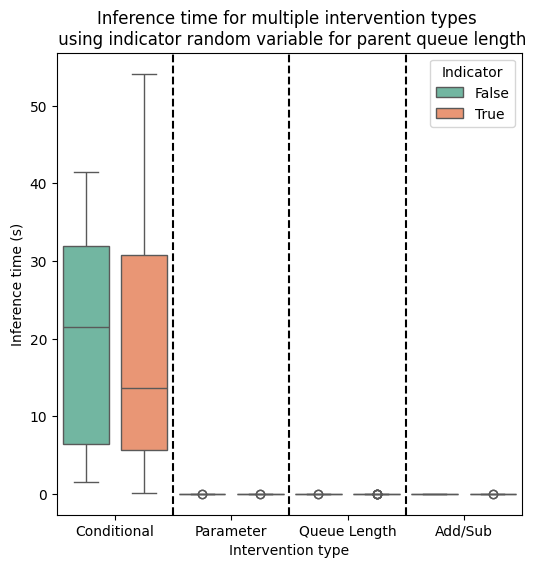

In [19]:
# Create a boxplot of the inference times for expt_indicator_df. The y-axis is the inference times, and the x-axis is the intervention type. The boxplot should be split by the 'Indicator' column.
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_time', hue='Indicator', data=expt_indicator_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time for multiple intervention types \n using indicator random variable for parent queue length')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.show()

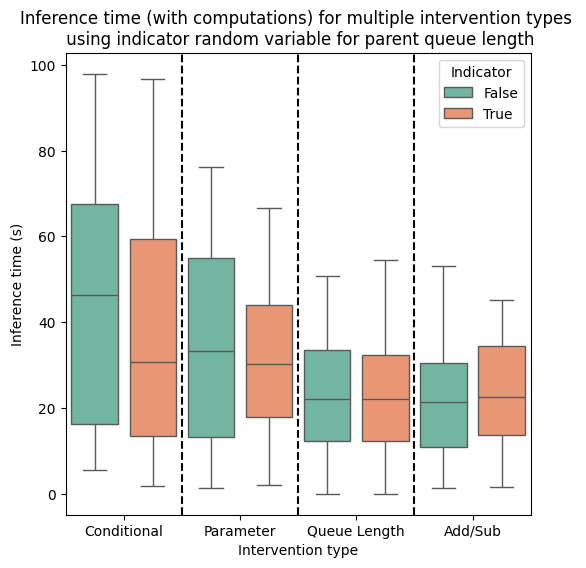

In [20]:
# Create a boxplot of the inference times for expt_indicator_df. The y-axis is the inference times, and the x-axis is the intervention type. The boxplot should be split by the 'Indicator' column.
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_compute_time', hue='Indicator', data=expt_indicator_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time (with computations) for multiple intervention types \n using indicator random variable for parent queue length')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.show()

In [21]:
# Groupby the rows based on the table 'Intervention Type' and compute the mean of the 'jsd' and 'inference_time' columns
grouped_full_df = df1_types.groupby('Intervention Type').agg({'jsd': 'mean', 'inference_time': 'mean', 'inference_compute_time': 'mean'}).reset_index()
print(grouped_full_df)

  Intervention Type       jsd  inference_time  inference_compute_time
0           Add/Sub  0.068046        0.002959               21.507413
1       Conditional  0.087735       20.274118               43.519621
2         Parameter  0.054972        0.003111               32.146283
3      Queue Length  0.062599        0.002937               22.964515


In [22]:
# Groupby the rows based on the table 'Intervention Type' and 'Indicator' and compute the mean of the 'jsd' and 'inference_time' columns
grouped_indicator_df = expt_indicator_df.groupby(['Intervention Type', 'Indicator']).agg({'jsd': 'mean', 'inference_time': 'mean', 'inference_compute_time': 'mean'}).reset_index()
print(grouped_indicator_df)

  Intervention Type  Indicator       jsd  inference_time  \
0           Add/Sub      False  0.068046        0.002959   
1           Add/Sub       True  0.042331        0.002140   
2       Conditional      False  0.087735       20.274118   
3       Conditional       True  0.138657       18.684928   
4         Parameter      False  0.054972        0.003111   
5         Parameter       True  0.047635        0.002394   
6      Queue Length      False  0.062599        0.002937   
7      Queue Length       True  0.052421        0.002250   

   inference_compute_time  
0               21.507413  
1               23.649191  
2               43.519621  
3               38.991034  
4               32.146283  
5               29.791808  
6               22.964515  
7               22.174725  


## Approximate Inference - Loopy Belief Propagation

In [20]:
INDICATOR = False
INFERENCE_METHOD = 'approx-lbf'
NREPS = 30
df3 = read_results_file(INDICATOR, INFERENCE_METHOD, NREPS)

In [ ]:
# Find the average of the 'jsd' in df3 where intv_type = 'conditional' and 'exp_num' is in df1_conditional_rows_list
df3_conditional_vals = df3[(df3['intv_type'] == 'conditional') & (df3['exp_num'].isin(df1_conditional_rows_list))][['exp_num', 'jsd']]
# print(f'JSD values for df3 where intv_type = conditional and exp_num is in df1_conditional_rows_list: \n{df3_conditional_vals}')
df3_conditional_jsd = df3_conditional_vals['jsd'].mean()
print(f'Average JSD for df3 where intv_type = conditional and exp_num is in df1_conditional_rows_list for LBF: {df3_conditional_jsd}')

In [ ]:
# Find the average of the 'jsd' in df3 where intv_type = 'parameter_intervention'
df3_param_intv = df3.loc[df3['intv_type'] == 'parameter_intervention', 'jsd'].mean()
print(f'Average JSD for parameter intervention using exact-lazypropr: {df1_param_intv}')
print(f'Average JSD for parameter intervention using approx-lbf: {df3_param_intv}')

# Find percentage increase in error between exact-lazyprop and approx-lbf
percent_increase_lbf = ((df3_param_intv - df1_param_intv) / df3_param_intv) * 100
print(f'Percentage increase in error using approx-lbf: {percent_increase_lbf:.3f}%')

In [ ]:
# Find the average of the 'jsd' in df3 where intv_type = 'interventional'
df3_int_intv = df3.loc[df3['intv_type'] == 'interventional', 'jsd'].mean()

print(f'Average JSD for interventional intervention using exact-lazyprop: {df1_int_intv}')
print(f'Average JSD for interventional intervention using approx-lbf: {df3_int_intv}')

# Find percentage increase in error between exact-lazyprop and approx-lbf
percent_increase_lbf = ((df3_int_intv - df1_int_intv) / df3_int_intv) * 100
print(f'Percentage increase in error using approx-lbf: {percent_increase_lbf:.3f}%')

In [ ]:
# Find the average of the 'jsd' in df3 where intv_type = 'additive' or 'subtractive'
df3_add_sub_intv = df3.loc[df3['intv_type'].isin(['additive', 'subtractive']), 'jsd'].mean()
print(f'Average JSD for additive/subtractive intervention using exact-lazyprop: {df1_add_sub_intv}')
print(f'Average JSD for additive/subtractive intervention using approx-lbf: {df3_add_sub_intv}')

# Find percentage increase in error between exact-lazyprop and approx-lbf
percent_increase_lbf = ((df3_add_sub_intv - df1_add_sub_intv) / df3_add_sub_intv) * 100
print(f'Percentage increase in error using approx-lbf: {percent_increase_lbf:.3f}%')

In [ ]:
# Find the average of the 'jsd' in df3 where intv_type = 'interventional' or 'additive' or 'subtractive' or 'parameter_intervention'
df3_all_intv = df3.loc[df3['intv_type'].isin(['interventional', 'additive', 'subtractive', 'parameter_intervention']), 'jsd'].mean()
print(f'Average JSD for all interventions using exact-lazyprop: {df1_all_intv}')
print(f'Average JSD for all interventions using approx-lbf: {df3_all_intv}')

# Find percentage increase in error between exact-lazyprop and approx-lbf
percent_increase_lbf = ((df3_all_intv - df1_all_intv) / df3_all_intv) * 100
print(f'Percentage increase in error using approx-lbf: {percent_increase_lbf:.3f}%')

In [ ]:
# Drop rows in df3 where expt_num is in drop_rows
df3 = df3[~df3['exp_num'].isin(drop_rows)]
# Find the average of the 'jsd' in df3
df3_jsd = df3['jsd'].mean()
print(f'Average JSD for df3: {df3_jsd}')

# Find the percentage increase in error using df3 compared to df1
percent_increase = ((df3_jsd - df1_jsd) / df3_jsd) * 100
print(f'Percentage increase in error using approx-lbf: {percent_increase:.3f}%')


In [27]:
# Combine df1 and df3 into a single dataframe called expt_inference_df, with an additional column called 'Inference Method' which will have the values 'Exact' for df1 and 'Approx-LBF' for df3
df1['Inference Method'] = 'Exact'
df3['Inference Method'] = 'Approx-LBF'
expt_inference_df = pd.concat([df1, df3])
expt_inference_df.reset_index(drop=True, inplace=True)

In [ ]:
# Create a column called 'Intervention Type' in expt_inference_df which will have the values 'Conditional', 'Parameter Intervention', 'Interventional', 'Additive/Subtractive Intervention' based on the value of 'intv_type'
expt_inference_df['Intervention Type'] = expt_inference_df['intv_type'].apply(lambda x: 'Conditional' if x == 'conditional' else ('Parameter' if x == 'parameter_intervention' else ('Queue Length' if x == 'interventional' else 'Add/Sub')))
# Create a boxplot of the JSD values for expt_inference_df. The y-axis is the JSD values, and the x-axis is the intervention type. The boxplot should be split by the 'Inference Method' column.
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='jsd', hue='Inference Method', data=expt_inference_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Jensen-Shannon distance for multiple intervention types \n using exact and loopy belief propagation inference methods')
plt.xlabel('Intervention type')
plt.ylabel('Jensen-Shannon Distance (JSD)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.ylim(0, 0.8)
plt.show()

In [ ]:
# Create the same plot as above, but for inference_time instead of jsd on the y-axis
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_time', hue='Inference Method', data=expt_inference_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time for multiple intervention types \n using exact and loopy belief propagation inference methods')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.show()

In [ ]:
# Create the same plot as above - for inference_time, but only for 'Parameter', 'Queue Length' and 'Add/Sub' intervention types
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_time', hue='Inference Method', data=expt_inference_df[expt_inference_df['Intervention Type'] != 'Conditional'], palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time using exact and \n loopy belief propagation inference methods')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.ylim(0, 0.01)
plt.show()


In [ ]:
# Create the same plot as above, but for inference_compute_time instead of inference_time on the y-axis
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_compute_time', hue='Inference Method', data=expt_inference_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time (with computations) for multiple intervention types \n using exact and loopy belief propagation inference methods')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.show()

## Approximate Inference - Monte Carlo Sampling

In [23]:
INFERENCE_METHOD = 'approx-mcs'
INDICATOR = False
df4 = read_results_file(INDICATOR, INFERENCE_METHOD, NREPS)

In [24]:
# Find the average of the 'jsd' in df4 where intv_type = 'conditional' and 'exp_num' is in df1_conditional_rows_list
df4_conditional_vals = df4[(df4['intv_type'] == 'conditional') & (df4['exp_num'].isin(df1_conditional_rows_list))][['exp_num', 'jsd']]
# print(f'JSD values for df4 where intv_type = conditional and exp_num is in df1_conditional_rows_list: \n{df4_conditional_vals}')
df4_conditional_jsd = df4_conditional_vals['jsd'].mean()
print(f'Average JSD for df4 where intv_type = conditional and exp_num is in df1_conditional_rows_list for Gibbs: {df4_conditional_jsd}')

Average JSD for df4 where intv_type = conditional and exp_num is in df1_conditional_rows_list for Gibbs: 0.09314204088287098


In [25]:

# Find the average of the 'jsd' in df4 where intv_type = 'parameter_intervention'
df4_param_intv = df4.loc[df4['intv_type'] == 'parameter_intervention', 'jsd'].mean()
print(f'Average JSD for parameter intervention using exact-lazypropr: {df1_param_intv}')
print(f'Average JSD for parameter intervention using approx-mcs: {df4_param_intv}')


# Find percentage increase in error between exact-lazyprop and approx-gibbs
percent_increase_gibbs = ((df4_param_intv - df1_param_intv) / df4_param_intv) * 100
print(f'Percentage increase in error using approx-mcs: {percent_increase_gibbs:.3f}%')

Average JSD for parameter intervention using exact-lazypropr: 0.054971623558243594
Average JSD for parameter intervention using approx-mcs: 0.07102357946334532
Percentage increase in error using approx-mcs: 22.601%


In [26]:

# Find the average of the 'jsd' in df4 where intv_type = 'interventional'
df4_int_intv = df4.loc[df4['intv_type'] == 'interventional', 'jsd'].mean()

print(f'Average JSD for interventional intervention using exact-lazyprop: {df1_int_intv}')
print(f'Average JSD for interventional intervention using approx-mcs: {df4_int_intv}')


# Find percentage increase in error between exact-lazyprop and approx-gibbs
percent_increase_gibbs = ((df4_int_intv - df1_int_intv) / df4_int_intv) * 100
print(f'Percentage increase in error using approx-mcs: {percent_increase_gibbs:.3f}%')

Average JSD for interventional intervention using exact-lazyprop: 0.06259928160693337
Average JSD for interventional intervention using approx-mcs: 0.10949253576350122
Percentage increase in error using approx-mcs: 42.828%


In [27]:

# Find the average of the 'jsd' in df4 where intv_type = 'additive' or 'subtractive'
df4_add_sub_intv = df4.loc[df4['intv_type'].isin(['additive', 'subtractive']), 'jsd'].mean()

print(f'Average JSD for additive/subtractive intervention using exact-lazyprop: {df1_add_sub_intv}')
print(f'Average JSD for additive/subtractive intervention using approx-mcs: {df4_add_sub_intv}')



# Find percentage increase in error between exact-lazyprop and approx-gibbs
percent_increase_gibbs = ((df4_add_sub_intv - df1_add_sub_intv) / df4_add_sub_intv) * 100
print(f'Percentage increase in error using approx-mcs: {percent_increase_gibbs:.3f}%')


Average JSD for additive/subtractive intervention using exact-lazyprop: 0.06804555336052638
Average JSD for additive/subtractive intervention using approx-mcs: 0.13428412749760305
Percentage increase in error using approx-mcs: 49.327%


In [28]:

# Find the average of the 'jsd' in df4 where intv_type = 'interventional' or 'additive' or 'subtractive' or 'parameter_intervention'
df4_all_intv = df4.loc[df4['intv_type'].isin(['interventional', 'additive', 'subtractive', 'parameter_intervention']), 'jsd'].mean()
print(f'Average JSD for all interventions using exact-lazyprop: {df1_all_intv}')
print(f'Average JSD for all interventions using approx-mcs: {df4_all_intv}')



# Find percentage increase in error between exact-lazyprop and approx-gibbs
percent_increase_gibbs = ((df4_all_intv - df1_all_intv) / df4_all_intv) * 100
print(f'Percentage increase in error using approx-mcs: {percent_increase_gibbs:.3f}%')

Average JSD for all interventions using exact-lazyprop: 0.0618672727830754
Average JSD for all interventions using approx-mcs: 0.1049334142414832
Percentage increase in error using approx-mcs: 41.041%


In [29]:
# Drop rows in df4 where expt_num is in drop_rows
df4 = df4[~df4['exp_num'].isin(drop_rows)]

# Find the average of the 'jsd' in df4
df4_jsd = df4['jsd'].mean()
print(f'Average JSD for df4: {df4_jsd}')

# Find the percentage increase in error using df4 compared to df1
percent_increase = ((df4_jsd - df1_jsd) / df4_jsd) * 100
print(f'Percentage increase in error using approx-mcs: {percent_increase:.3f}%')

Average JSD for df4: 0.10330701791615739
Percentage increase in error using approx-mcs: 36.639%


In [30]:
# Combine df1 and df4 into a single dataframe called expt_inference_df, with an additional column called 'Inference Method' which will have the values 'Exact' for df1 and 'Approx-MCS' for df4
df1['Inference Method'] = 'Exact'
df4['Inference Method'] = 'Approx-MCS'
expt_inference_df = pd.concat([df1, df4])
expt_inference_df.reset_index(drop=True, inplace=True)

# Create a column called 'Intervention Type' in expt_inference_df which will have the values 'Conditional', 'Parameter Intervention', 'Interventional', 'Additive/Subtractive Intervention' based on the value of 'intv_type'
expt_inference_df['Intervention Type'] = expt_inference_df['intv_type'].apply(lambda x: 'Conditional' if x == 'conditional' else ('Parameter' if x == 'parameter_intervention' else ('Queue Length' if x == 'interventional' else 'Add/Sub')))

# Find the percent change in 'jsd' and 'inference_time' between exact and approx-mcs
grouped_inference_df = expt_inference_df.groupby(['Intervention Type', 'Inference Method']).agg({'jsd': 'mean', 'inference_time': 'mean', 'inference_compute_time': 'mean'}).reset_index()
print(grouped_inference_df)


  Intervention Type Inference Method       jsd  inference_time  \
0           Add/Sub       Approx-MCS  0.134284        0.000062   
1           Add/Sub            Exact  0.068046        0.002959   
2       Conditional       Approx-MCS  0.093142      404.662041   
3       Conditional            Exact  0.087735       20.274118   
4         Parameter       Approx-MCS  0.071024        0.000051   
5         Parameter            Exact  0.054972        0.003111   
6      Queue Length       Approx-MCS  0.109493        0.000052   
7      Queue Length            Exact  0.062599        0.002937   

   inference_compute_time  
0               42.455157  
1               21.507413  
2              449.885560  
3               43.519621  
4               49.959056  
5               32.146283  
6               48.133518  
7               22.964515  


In [31]:
# Compute the percentage change in 'jsd' and 'inference_time' between exact and approx-mcs
mean_jsd_exact = df1['jsd'].mean()
mean_jsd_mcs = df4['jsd'].mean()
percent_change_jsd = ((mean_jsd_mcs - mean_jsd_exact) / mean_jsd_mcs) * 100
print(f'Percentage change in JSD using approx-mcs: {percent_change_jsd:.3f}%')

mean_inference_time_exact = df1['inference_time'].mean()
mean_inference_time_mcs = df4['inference_time'].mean()
print(f'Mean inference time using exact-lazyprop: {mean_inference_time_exact}')
print(f'Mean inference time using approx-mcs: {mean_inference_time_mcs}')
percent_change_inference_time = ((mean_inference_time_mcs - mean_inference_time_exact) / mean_inference_time_mcs) * 100
print(f'Percentage change in inference time using approx-mcs: {percent_change_inference_time:.3f}%')

Percentage change in JSD using approx-mcs: 36.639%
Mean inference time using exact-lazyprop: 2.8151807151088826
Mean inference time using approx-mcs: 55.8155015707016
Percentage change in inference time using approx-mcs: 94.956%


In [32]:
# Compute the same only for the interventional queries 
mean_jsd_exact_intv = df1.loc[df1['intv_type'] != 'conditional', 'jsd'].mean()
mean_jsd_mcs_intv = df4.loc[df4['intv_type'] != 'conditional', 'jsd'].mean()
percent_change_jsd_intv = ((mean_jsd_mcs_intv - mean_jsd_exact_intv) / mean_jsd_mcs_intv) * 100
print(f'Percentage change in JSD for interventional queries using approx-mcs: {percent_change_jsd_intv:.3f}%')

mean_inference_time_exact_intv = df1.loc[df1['intv_type'] != 'conditional', 'inference_time'].mean()
mean_inference_time_mcs_intv = df4.loc[df4['intv_type'] != 'conditional', 'inference_time'].mean()
print(f'Mean inference time for interventional queries using exact-lazyprop: {mean_inference_time_exact_intv}')
print(f'Mean inference time for interventional queries using approx-mcs: {mean_inference_time_mcs_intv}')
percent_change_inference_time_intv = ((mean_inference_time_mcs_intv - mean_inference_time_exact_intv) / mean_inference_time_mcs_intv) * 100
print(f'Percentage change in inference time for interventional queries using approx-mcs: {percent_change_inference_time_intv:.3f}%')

Percentage change in JSD for interventional queries using approx-mcs: 41.041%
Mean inference time for interventional queries using exact-lazyprop: 0.0030028211990458377
Mean inference time for interventional queries using approx-mcs: 5.530675252278475e-05
Percentage change in inference time for interventional queries using approx-mcs: -5329.393%


In [ ]:
# Create a column called 'Inference Method' in df4 which will have the value 'Approx-MCS'
df4['Inference Method'] = 'Approx-MCS'
# Combine df1, df3 and df4 into a single dataframe called expt_inference_df, with an additional column called 'Inference Method' which will have the values 'Exact', 'Approx-LBF' and 'Approx-MCS'
expt_inference_df = pd.concat([df1, df3, df4])
expt_inference_df.reset_index(drop=True, inplace=True)

# Create a column called 'Intervention Type' in expt_inference_df which will have the values 'Conditional', 'Parameter Intervention', 'Interventional', 'Additive/Subtractive Intervention' based on the value of 'intv_type'
expt_inference_df['Intervention Type'] = expt_inference_df['intv_type'].apply(lambda x: 'Conditional' if x == 'conditional' else ('Parameter' if x == 'parameter_intervention' else ('Queue Length' if x == 'interventional' else 'Add/Sub')))

# Create a boxplot of the JSD values for expt_inference_df. The y-axis is the JSD values, and the x-axis is the intervention type. The boxplot should be split by the 'Inference Method' column.
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='jsd', hue='Inference Method', data=expt_inference_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Jensen-Shannon distance for multiple intervention types \n using exact and approximate inference methods')
plt.xlabel('Intervention type')
plt.ylabel('Jensen-Shannon Distance (JSD)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.ylim(0, 1.0)
plt.show()

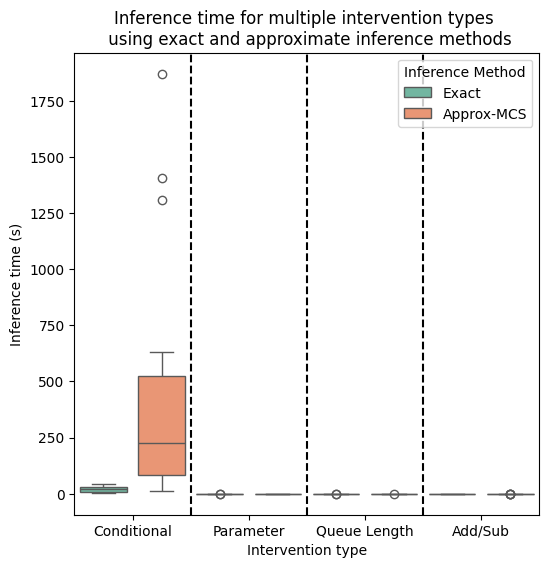

In [34]:
# Create the same plot as above, but for inference_time instead of jsd on the y-axis
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_time', hue='Inference Method', data=expt_inference_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time for multiple intervention types \n using exact and approximate inference methods')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.show()

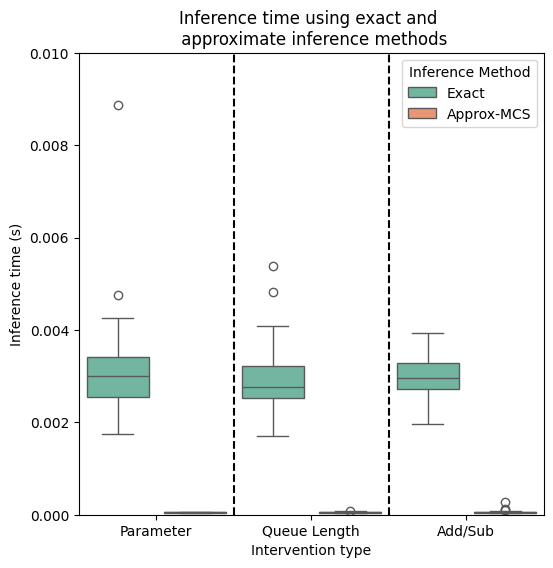

In [35]:
# Create the same plot as above - for inference_time, but only for 'Parameter', 'Queue Length' and 'Add/Sub' intervention types
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_time', hue='Inference Method', data=expt_inference_df[expt_inference_df['Intervention Type'] != 'Conditional'], palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time using exact and \n approximate inference methods')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.ylim(0, 0.01)
plt.show()

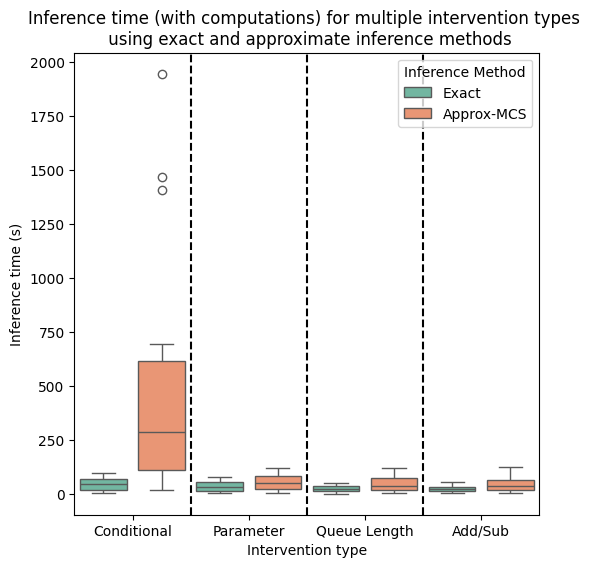

In [36]:
# Create the same plot as above, but for inference_compute_time instead of inference_time on the y-axis
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='inference_compute_time', hue='Inference Method', data=expt_inference_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time (with computations) for multiple intervention types \n using exact and approximate inference methods')
plt.xlabel('Intervention type')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.show()

## Number of replications

We now study the impact of the number of replications on the accuracy of the queries. 

In [43]:
INDICATOR = False
INFERENCE_METHOD = 'exact-lazyprop'
nr_dfs = []
for nreps in range(10, 110, 10): 
    nr_dfs.append(read_results_file(INDICATOR, INFERENCE_METHOD, nreps))
    
# For each of the dataframes in nr_dfs, add a column called 'num_reps' which will have the value of the number of repetitions used to generate the dataframe
for i, df in enumerate(nr_dfs):
    df['num_reps'] = 10 * (i + 1)
    
# Combine all the dataframes in nr_dfs into a single dataframe called expt_nr_df
expt_nr_df = pd.concat(nr_dfs)
expt_nr_df.reset_index(drop=True, inplace=True)

# Create a column called 'Intervention Type' in expt_nr_df which will have the values 'Conditional', 'Parameter Intervention', 'Interventional', 'Additive/Subtractive Intervention' based on the value of 'intv_type'
expt_nr_df['Intervention Type'] = expt_nr_df['intv_type'].apply(lambda x: 'Conditional' if x == 'conditional' else ('Parameter' if x == 'parameter_intervention' else ('Queue Length' if x == 'interventional' else 'Add/Sub')))

# Drop those rows in expt_nr_df where exp_num is in drop_rows
expt_nr_df = expt_nr_df[~expt_nr_df['exp_num'].isin(drop_rows)]

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 6), 
                               gridspec_kw={'height_ratios': [0.03, 1]})

# Adjust spacing between the plots
fig.subplots_adjust(hspace=0.03)

sns.boxplot(x='num_reps', y='jsd', data=expt_nr_df, gap=0.2, width=1.0, legend=True, ax=ax2, fill=False, linecolor='black', color='black', linewidth=0.8, fliersize=1.5)
ax2.set_ylim(0, 0.45)

sns.boxplot(x='num_reps', y='jsd', data=expt_nr_df, gap=0.2, width=1.0, legend=False, ax=ax1)
# Remove y-axis labels from the top plot
ax1.set_ylabel('')
ax1.set_ylim(0.99, 1.0)
# Show only the top ytick label on the top plot
ax1.set_yticks([1])
ax1.set_yticklabels([1.0])

# Hide the spines between the plots
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Hide the x-axis tick labels on the first plot
ax1.tick_params(labelbottom=False)

# Add diagonal lines to indicate the axis break
d = 0.015  # Size of the diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

d = 0.015  # Size of the diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# How to remove the '''' lines from the plot
ax1.xaxis.tick_top()
# Do not show ticks on the top plot
ax1.tick_params(top=False)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top

# Show the plot
# Add title to the full plot
plt.suptitle(r'JSD for varying number of replications $N$ per design point')
plt.xlabel(r'Number of replications $N$ per design point')
plt.ylabel(f'Jensen-Shannon distance (JSD)')
plt.tight_layout()
plt.savefig('../figures/journal_figures/nreps_avg_jsd.png', dpi=300)
plt.show()

In [ ]:
# Create a boxplot of the JSD values for expt_nr_df. The y-axis is the JSD values, and the x-axis is the number of repetitions. The boxplot should be split by the 'num_reps' column.
fig= plt.figure(figsize=(6, 6))
ax = plt.gca()
sns.boxplot(x='num_reps', y='jsd', data=expt_nr_df, palette='Set2', gap=0.2, width=1.0, legend=True, ax=ax)
ax.set_ylim(0, 0.5)
ax.axhline(y=0.5, color='k', linestyle='--')
plt.title(r'Average JSD for varying number of replications $N$ per design point')
plt.xlabel(r'Number of replications $N$')
plt.ylabel(f'Jensen-Shannon distance (JSD)')
plt.show()

In [ ]:
# Create the same boxplot as above, but split by the intervention type
plt.figure(figsize=(12, 6))
sns.boxplot(hue='num_reps', y='jsd', x='Intervention Type', data=expt_nr_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Jensen-Shannon distance for different number of repetitions \n split by intervention type')
plt.xlabel('Number of repetitions')
plt.ylabel('Jensen-Shannon Distance (JSD)')
plt.ylim(0, 1.0)
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
# Make legend at the top right corner of the plot 
plt.legend()
plt.show()

In [ ]:
# Create the same boxplot as above, but for the inference_time on the y-axis
plt.figure(figsize=(12, 6))
sns.boxplot(hue='num_reps', y='inference_time', x='Intervention Type', data=expt_nr_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time for different number of repetitions \n split by intervention type')
plt.xlabel('Number of repetitions')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
# Make legend at the top right corner of the plot
plt.legend()
plt.show()


In [ ]:
# Make the same plot as above, but for all groups except 'Conditional'
plt.figure(figsize=(12, 6))
sns.boxplot(hue='num_reps', y='inference_time', x='Intervention Type', data=expt_nr_df[expt_nr_df['Intervention Type'] != 'Conditional'], palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time for different number of repetitions \n split by intervention type')
plt.xlabel('Number of repetitions')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.ylim(0, 0.01)
# Place the legend at the top right corner of the plot
plt.legend(loc='upper right')
plt.show()

In [ ]:
# Create the same boxplot as above, but for the inference_compute_time on the y-axis
plt.figure(figsize=(12, 6))
sns.boxplot(hue='num_reps', y='inference_compute_time', x='Intervention Type', data=expt_nr_df, palette='Set2', legend=True, gap=0.2, width=1.0)
plt.title('Inference time (with computations) for different number of repetitions \n split by intervention type')
plt.xlabel('Number of repetitions')
plt.ylabel('Inference time (s)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
# Make legend at the top right corner of the plot
plt.legend(loc='upper right')
plt.show()

## Pooling vs. non pooling 

Here we explore the results for pooling vs. without pooling. The simulation configuration experiment is '12'. 

In [37]:
# Function to read the results file for the specified settings
def read_pooled_results_file(indicator,
                      inference_method,
                      nreps,
                      pooling):
    filename = f'../results/indicator-{indicator}_inference-{inference_method}_nreps-{nreps}_pooled-{pooling}_results.csv'
    df = pd.read_csv(filename)
    return df

In [38]:
INDICATOR = False
INFERENCE_METHOD = 'exact-lazyprop'
NREPS = 30
pooling = True 
df_pooled = read_pooled_results_file(INDICATOR, INFERENCE_METHOD, NREPS, pooling)

pooling = False 
df_not_pooled = read_pooled_results_file(INDICATOR, INFERENCE_METHOD, NREPS, pooling)

In [39]:
# Find exp_num of columns in df1 where intv_type = conditional and 'number_conditional_events' <= 50
drop_rows_pooled = df_pooled[(df_pooled['intv_type'] == 'conditional') & (df_pooled['num_conditional_events'] <= 50)].exp_num.tolist()
print(f'List of rows in df1 where intv_type = conditional and number_conditional_events <= 50: {drop_rows_pooled}')

List of rows in df1 where intv_type = conditional and number_conditional_events <= 50: [2, 4, 14, 15, 17, 19, 20, 28, 29, 30, 31, 32, 33, 34, 36, 43, 49]


In [43]:
# Drop rows in df1 where expt_num is in drop_rows
df_pooled = df_pooled[~df_pooled['exp_num'].isin(drop_rows_pooled)]

# Find the average of the 'jsd' in df1
df_pooled_jsd = df_pooled['jsd'].mean()
print(f'Average JSD for df with pooling: {df_pooled_jsd}')

# Drop rows in df2 where expt_num is in drop_rows
df_not_pooled_jsd = df_not_pooled[~df_not_pooled['exp_num'].isin(drop_rows)]
df_not_pooled_jsd  = df_not_pooled['jsd'].mean()
print(f'Average JSD for df without pooling: {df_not_pooled_jsd}')

# Find the percentage decrease in error using df2 compared to df1
percent_decrease = ((df_not_pooled_jsd - df_pooled_jsd) / df_not_pooled_jsd) * 100
print(f'Percentage decrease in error using pooled data when compared to not: {percent_decrease}')

Average JSD for df with pooling: 0.06434321643358155
Average JSD for df without pooling: 0.09771828352498127
Percentage decrease in error using pooled data when compared to not: 34.15437304817938


In [44]:
# Create table to get the average JSD using pooling
df_pooled_types = df_pooled.copy()
# Create an additional column in df1_types called 'intv_category' which will have the values 'conditional', 'parameter_intervention', 'interventional', 'additive/subtractive' based on the value of 'intv_type'
df_pooled_types['Intervention Type'] = df_pooled_types['intv_type'].apply(lambda x: 'Conditional' if x == 'conditional' else ('Parameter' if x == 'parameter_intervention' else ('Queue Length' if x == 'interventional' else 'Add/Sub')))

# Create table to get the average JSD using pooling
df_not_pooled_types = df_not_pooled.copy()
# Create an additional column in df1_types called 'intv_category' which will have the values 'conditional', 'parameter_intervention', 'interventional', 'additive/subtractive' based on the value of 'intv_type'
df_not_pooled_types['Intervention Type'] = df_not_pooled_types['intv_type'].apply(lambda x: 'Conditional' if x == 'conditional' else ('Parameter' if x == 'parameter_intervention' else ('Queue Length' if x == 'interventional' else 'Add/Sub')))

In [47]:
# Group by "Intervention Type" and get the average JSD. 
grouped_pooling = df_pooled_types.groupby(['Intervention Type']).agg({'jsd': 'mean', 'inference_time': 'mean', 'inference_compute_time': 'mean'}).reset_index()
print(grouped_pooling)

  Intervention Type       jsd  inference_time  inference_compute_time
0           Add/Sub  0.064010        0.002556                9.906232
1       Conditional  0.091603       10.385561               22.524902
2         Parameter  0.056873        0.002665               13.203410
3      Queue Length  0.057971        0.002450               11.106456


In [48]:
grouped_not_pooling = df_not_pooled_types.groupby(['Intervention Type']).agg({'jsd': 'mean', 'inference_time': 'mean', 'inference_compute_time': 'mean'}).reset_index()
print(grouped_not_pooling)

  Intervention Type       jsd  inference_time  inference_compute_time
0           Add/Sub  0.086020        0.002465                9.976959
1       Conditional  0.188006       10.069179               21.747382
2         Parameter  0.066231        0.002412               11.910909
3      Queue Length  0.078750        0.002535               12.211987


In [80]:
# Group them together and create a boxplot of their comparison. 
df_pooled['Pooling'] = True
df_not_pooled['Pooling'] = False
df_pooling_expt = pd.concat([df_pooled, df_not_pooled])
df_pooling_expt.reset_index(drop=True, inplace=True)

# Create a column called 'Intervention Type' in expt_inference_df which will have the values 'Conditional', 'Parameter Intervention', 'Interventional', 'Additive/Subtractive Intervention' based on the value of 'intv_type'
df_pooling_expt['Intervention Type'] = df_pooling_expt['intv_type'].apply(lambda x: 'Conditional' if x == 'conditional' else ('Parameter' if x == 'parameter_intervention' else ('Queue Length' if x == 'interventional' else 'Add/Sub')))
df_pooling_expt.head()

,exp_num,expt_name,intv_type,intv_var,intv_time,intv_val,query_var,query_time,queue_setting,jsd,num_conditional_events,inference_time,inference_compute_time,Pooling,Intervention Type
0,1,indicator-False_inference-exact-lazyprop_nreps...,conditional,Lqc,1.6,1.0,Lqc,2.4,pooled-True,0.052162,1486.0,6.106624,15.206529,True,Conditional
1,5,indicator-False_inference-exact-lazyprop_nreps...,conditional,Lqc,1.0,2.0,Lqc,5.0,pooled-True,0.026487,1566.0,23.721683,51.126253,True,Conditional
2,6,indicator-False_inference-exact-lazyprop_nreps...,conditional,Lqb,0.2,2.0,Lqa,0.6,pooled-True,0.147862,66.0,0.098533,1.623179,True,Conditional
3,7,indicator-False_inference-exact-lazyprop_nreps...,conditional,Lqa,0.2,0.0,Lqb,1.0,pooled-True,0.075761,871.0,3.628142,10.516066,True,Conditional
4,8,indicator-False_inference-exact-lazyprop_nreps...,conditional,Lqc,3.4,0.0,Lqc,3.8,pooled-True,0.089090,299.0,23.132188,46.937051,True,Conditional


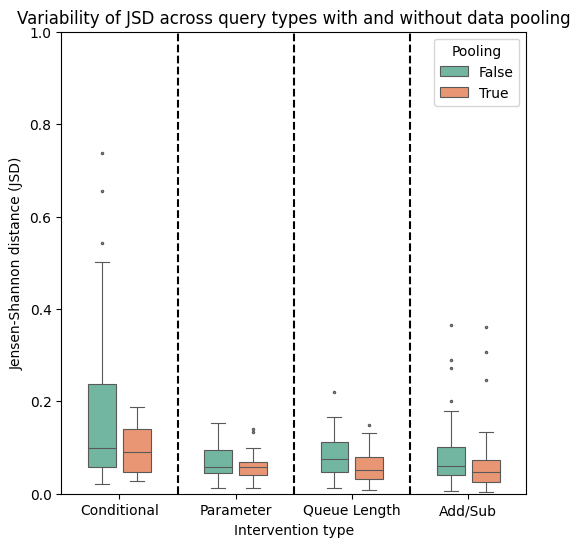

In [81]:
# Create the same plot as above, but for inference_time instead of jsd on the y-axis
plt.figure(figsize=(6, 6))
sns.boxplot(x='Intervention Type', y='jsd', hue='Pooling', data=df_pooling_expt, palette='Set2', legend=True, gap=0.2, width=0.6, linewidth=0.8, fliersize=1.5)
plt.title('Variability of JSD across query types with and without data pooling')
plt.xlabel('Intervention type')
plt.ylabel('Jensen-Shannon distance (JSD)')
# Add a line between the groups
plt.axvline(0.5, color='black', linestyle='--')
plt.axvline(1.5, color='black', linestyle='--')
plt.axvline(2.5, color='black', linestyle='--')
plt.ylim(0, 1)
plt.show()

[False  True]


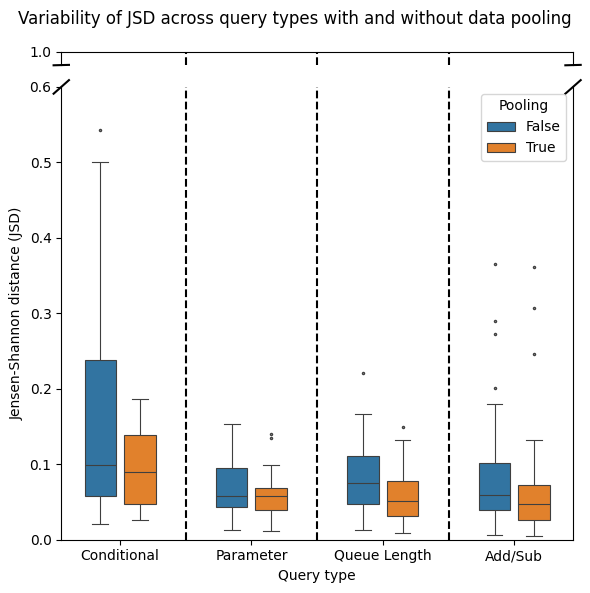

In [103]:
# Create a plot that is good for the journal paper. More professional.
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 6), 
                               gridspec_kw={'height_ratios': [0.03, 1]})

# Adjust spacing between the plots
fig.subplots_adjust(hspace=0.03)

group_order=df_pooling_expt['Pooling'].unique()[::-1]
print(group_order)
sns.boxplot(x='Intervention Type', y='jsd', hue='Pooling', data=df_pooling_expt, gap=0.2, width=0.6, legend=True, ax=ax2, linewidth=0.8, fliersize=1.5, hue_order=group_order)
ax2.set_ylim(0, 0.6)
sns.boxplot(x='Intervention Type', y='jsd', hue='Pooling', data=df_pooling_expt, gap=0.2, width=0.6, legend=False, ax=ax1, hue_order=group_order)
# Remove y-axis labels from the top plot
ax1.set_ylabel('')
ax1.set_ylim(0.99, 1.0)
# Show only the top ytick label on the top plot
ax1.set_yticks([1])
ax1.set_yticklabels([1.0])

# Hide the spines between the plots
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Hide the x-axis tick labels on the first plot
ax1.tick_params(labelbottom=False)

# Add diagonal lines to indicate the axis break
d = 0.015  # Size of the diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

d = 0.015  # Size of the diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# How to remove the '''' lines from the plot
ax1.xaxis.tick_top()
# Do not show ticks on the top plot
ax1.tick_params(top=False)
ax1.tick_params(labeltop=False)  # don't put tick labels at the top

# Show the plot
# Add title to the full plot
plt.suptitle('Variability of JSD across query types with and without data pooling')
plt.xlabel('Query type')
plt.ylabel('Jensen-Shannon distance (JSD)')
# Add a line between the groups
ax1.axvline(0.5, color='black', linestyle='--')
ax1.axvline(1.5, color='black', linestyle='--')
ax1.axvline(2.5, color='black', linestyle='--')
ax2.axvline(0.5, color='black', linestyle='--')
ax2.axvline(1.5, color='black', linestyle='--')
ax2.axvline(2.5, color='black', linestyle='--')
plt.tight_layout()
# plt.legend(loc='upper right', bbox_to_anchor=(0.77, 1.07))
# plt.savefig('../figures/journal_figures/results-pooling-jsd.png', dpi=300)
plt.show()